In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/zahra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Tumor Benignity or Malignancy Detection Using Features Extracted from Microscopic Images Using Breast Cancer Dataset and MLP

#### Uploading data

In [2]:
df = pd.read_csv("breast_cancer.csv")

print(df.shape)
print(df.info())

print(df.describe()) # with due attention to the mean of each feature, we need normalization because they vary from 0.01 to 650 

print(df["Diagnosis"].value_counts()) # we have 357 samples of benign tumors and 212 samples of malignant tumors. (nearly balanced dataset)

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16

#### Spliting data into train and test sets

In [3]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

y = y.map({"B": 0, "M": 1}) # Labels are letters like 'B' and 'M'. So I convert them into 0 and 1.

In [4]:
np.random.seed(42)

X = X.values
y = y.values
n_samples = X.shape[0]
indices = np.random.permutation(n_samples) # shuffling data

train_size = int(0.8 * n_samples) # 80 percent for train and 20 percent for test
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


#### Normalizing data
we need normalization because features change in different scales.

In [5]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std # We normalize train and test data with mean and standard deviation of train data


print("Mean of normalized train (per feature):\n", X_train_norm.mean(axis=0))
print("Std of normalized train (per feature):\n", X_train_norm.std(axis=0))

# below we can see that averages are near 0 and standard deviations are 1. So data is normalized.

Mean of normalized train (per feature):
 [-2.92952475e-15  7.12494776e-16 -2.54985288e-15 -1.03994957e-15
  1.51167235e-15  9.76264246e-16 -3.90408097e-18  5.38031158e-16
 -3.05445535e-15 -1.00822891e-15 -3.87968046e-16 -1.70291132e-15
  6.06596580e-16 -2.78165769e-17  1.40937323e-15 -6.46613410e-17
 -5.56575543e-16  5.93908317e-16 -6.72721951e-16  2.45225086e-17
 -2.84753905e-15  8.89154440e-16  3.02810280e-16 -7.08346690e-16
  2.76042925e-15  2.61573425e-16  1.70803542e-18  1.01506105e-15
  6.71989936e-16  3.84917983e-16]
Std of normalized train (per feature):
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


#### 

#### Implementing neural network (MLP)

In [ ]:
class MLP:
    def __init__(self, input_dim, hidden1=16, hidden2=8, lr=0.01):
        self.lr = lr
        
        # initializing weights and biases using He Initialization for Relu activation function to prevent vanishing and exploding gradients
        self.W1 = np.random.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden1))
        
        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2.0 / hidden1)
        self.b2 = np.zeros((1, hidden2))
        
        self.W3 = np.random.randn(hidden2, 1) * np.sqrt(2.0 / hidden2)
        self.b3 = np.zeros((1, 1))
    

    # implementing activation functions (Relu and Sigmoid)
    def relu(self, Z):
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)
    
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))
    

    # forward pass
    def forward(self, X):
        Z1 = X @ self.W1 + self.b1       # (n, hidden1)
        A1 = self.relu(Z1)
        
        Z2 = A1 @ self.W2 + self.b2    # (n, hidden2)
        A2 = self.relu(Z2)
        
        Z3 = A2 @ self.W3 + self.b3     # (n, 1)
        A3 = self.sigmoid(Z3)           # A3=y_hat
        
        memory = {
            "X": X,
            "Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2,
            "Z3": Z3,
            "A3": A3    
        }
        return A3, memory
    

    # implementing cost function (BCE loss)
    def compute_loss(self, y_hat, y):
        eps = 1e-8  # to prevent passing 0 to the log function
        y_hat = np.clip(y_hat, eps, 1 - eps)
        m = y.shape[0]
        w = 1000 # for increasing recall by increasing the penalty of FN (w must be greater than 1)
        loss = - (1/m) * np.sum(w * y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)) # Binary Cross Entropy cost function
        return loss
    

    # backward pass
    def backward(self, memory, y_hat, y):
       
        X  = memory["X"]
        A1 = memory["A1"]
        Z1 = memory["Z1"]
        A2 = memory["A2"]
        Z2 = memory["Z2"]
        A3 = memory["A3"]
        
        m = y.shape[0]
        y = y.reshape(-1, 1)
        
        # output layer gradients
        dZ3 = (y_hat - y) / m
        dW3 = A2.T @ dZ3                # (hidden2, 1)
        db3 = np.sum(dZ3, axis=0, keepdims=True)
        
        # second hidden layer gradients
        dA2 = dZ3 @ self.W3.T           # (n, hidden2)
        dZ2 = dA2 * self.relu_derivative(Z2)
        dW2 = A1.T @ dZ2                # (hidden1, hidden2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        # first hidden layer gradients
        dA1 = dZ2 @ self.W2.T           # (n, hidden1)
        dZ1 = dA1 * self.relu_derivative(Z1)
        dW1 = X.T @ dZ1                 # (input_dim, hidden1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        gradients = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2,
            "dW3": dW3,
            "db3": db3
        }
        return gradients
    
    # updating weights and biases
    def update_parameters(self, grads):
        self.W1 -= self.lr * grads["dW1"]
        self.b1 -= self.lr * grads["db1"]
        self.W2 -= self.lr * grads["dW2"]
        self.b2 -= self.lr * grads["db2"]
        self.W3 -= self.lr * grads["dW3"]
        self.b3 -= self.lr * grads["db3"]
    
    # predict output function
    def predict(self, X, threshold=0.5): # if we reduce threshold, recall will increase but precision and f1-score will decrease
        y_hat, _ = self.forward(X)
        return (y_hat >= threshold).astype(int) # if y_hat is bigger than 0.5 predicted class is 1, otherwise it's 0.


#### Model training and evaluation

Epoch 20/200, Loss = 131.2234, Train Accuracy = 0.6879
Epoch 40/200, Loss = 126.8106, Train Accuracy = 0.7714
Epoch 60/200, Loss = 121.7990, Train Accuracy = 0.8352
Epoch 80/200, Loss = 116.9569, Train Accuracy = 0.8725
Epoch 100/200, Loss = 112.0396, Train Accuracy = 0.8901
Epoch 120/200, Loss = 107.4659, Train Accuracy = 0.9077
Epoch 140/200, Loss = 103.1940, Train Accuracy = 0.9209
Epoch 160/200, Loss = 99.1883, Train Accuracy = 0.9341
Epoch 180/200, Loss = 95.6815, Train Accuracy = 0.9516
Epoch 200/200, Loss = 92.5139, Train Accuracy = 0.9560


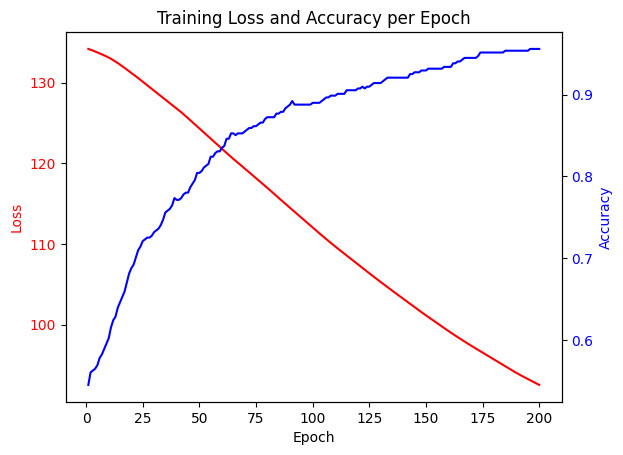

Final Train Accuracy: 0.9560
Final Test Accuracy : 0.9561


In [ ]:
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

input_dim = X_train_norm.shape[1]
model = MLP(input_dim=input_dim, hidden1=16, hidden2=10, lr=0.01)
num_epochs = 200
loss_history = []
accuracies=[]

for epoch in range(num_epochs):
    # forward pass
    y_hat, memory = model.forward(X_train_norm)
    
    # loss
    loss = model.compute_loss(y_hat, y_train)
    loss_history.append(loss)
    
    # backward pass
    gradients = model.backward(memory, y_hat, y_train)
    
    # update weights and biases
    model.update_parameters(gradients)
    
    # computing accuracy
    y_pred_train = model.predict(X_train_norm)
    accuracy_train = (y_pred_train.flatten() == y_train.flatten()).mean()
    accuracies.append(accuracy_train)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {loss:.4f}, Train Accuracy = {accuracy_train:.4f}")



epochs = range(1, len(loss_history) + 1)
fig, ax1 = plt.subplots()
# plot loss
ax1.plot(epochs, loss_history, color='red', label='Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# plot accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, accuracies, color='blue', label='Accuracy')
ax2.set_ylabel('Accuracy', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
plt.title('Training Loss and Accuracy per Epoch')
plt.show()



# evaluation on train and test data
y_pred_train = model.predict(X_train_norm).flatten()
y_pred_test  = model.predict(X_test_norm).flatten()

accuracy_train = (y_pred_train== y_train.flatten()).mean()
accuracy_test  = (y_pred_test  == y_test.flatten()).mean()

print(f"Final Train Accuracy: {accuracy_train:.4f}")
print(f"Final Test Accuracy : {accuracy_test:.4f}")


#### Confusion matrix - Precision - Recall - F1-score for test data

In [14]:
def confusion_matrix_binary(y_true, y_pred):
    y_true = y_true.flatten().astype(int)
    y_pred = y_pred.flatten().astype(int)
    
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix_binary(y_test, y_pred_test)
# print(y_pred_test)
print("Confusion Matrix:")
print("     Pred 0   Pred 1")
print(f"Real 0  {TN}    {FP}")
print(f"Real 1  {FN}    {TP}")
print()


def precision_recall_f1(TP, TN, FP, FN):
    eps = 1e-8
    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    return precision, recall, f1

precision, recall, f1 = precision_recall_f1(TP, TN, FP, FN)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Confusion Matrix:
     Pred 0   Pred 1
Real 0  69    3
Real 1  2    40

Precision : 0.9302
Recall    : 0.9524
F1-score  : 0.9412
